In [1]:
import numpy as np 
import pandas as pd 


In [2]:
df = pd.read_csv('Advertising (1).csv')
df

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900
...,...,...,...,...
195,38200,3700,13800,7600
196,94200,4900,8100,9700
197,177000,9300,6400,12800
198,283600,42000,66200,25500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         200 non-null    int64
 1   radio      200 non-null    int64
 2   newspaper  200 non-null    int64
 3   sales      200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [4]:
continuos = ['TV', 'radio', 'newspaper', 'sales']
df[continuos].describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147042.500000,23264.000000,30554.000000,14022.500000
std,85854.236315,14846.809176,21778.620839,5217.456566
min,700.000000,0.000000,300.000000,1600.000000
25%,74375.000000,9975.000000,12750.000000,10375.000000
50%,149750.000000,22900.000000,25750.000000,12900.000000
75%,218825.000000,36525.000000,45100.000000,17400.000000
max,296400.000000,49600.000000,114000.000000,27000.000000


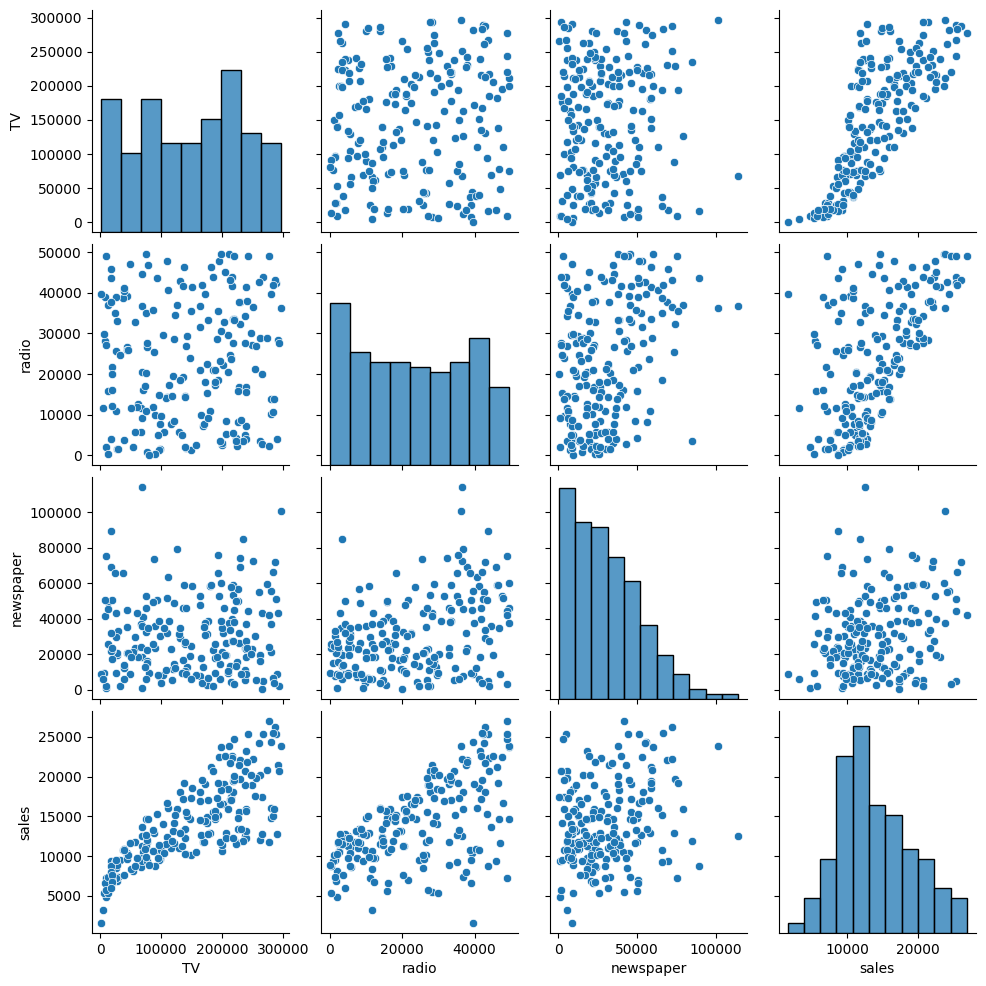

In [5]:
import seaborn as sns
sns.pairplot(df)

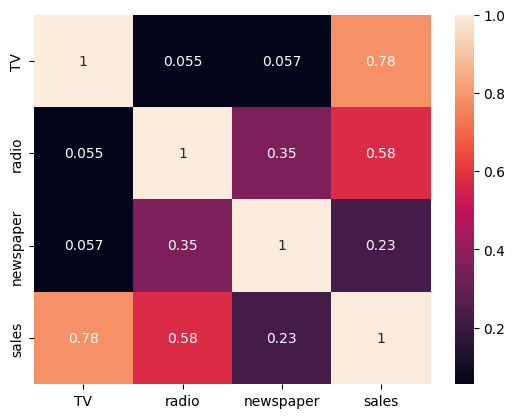

In [6]:
import matplotlib.pyplot as plt
sns.heatmap(df[continuos].corr(),annot=True)
plt.show()

In [7]:
X = df[['TV', 'radio', 'newspaper']]
y =df['sales']

In [51]:
Train = []
CV=[]
for i in range(1,100):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=i)
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(X_train,y_train)
    from sklearn.metrics import r2_score
    y_pred_train = model.predict(X_train)
    Train.append(r2_score(y_train,y_pred_train))
    from sklearn.model_selection import cross_val_score
    CV.append(cross_val_score(model, X, y, cv=5).mean())
    
em = pd.DataFrame({'Train':Train, 'CV':CV})
gm = em[abs(em['Train']-em['CV'])<=0.05]
rs = gm[gm['CV']==gm['CV'].max()].index.tolist()[0]
print('Best random state is:',rs)

Best random state is: 0


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [9]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

print('Intercept:',model.intercept_)
print('Coefficients:',model.coef_)

Intercept: 2994.8930304953265
Coefficients: [ 0.04458402  0.19649703 -0.00278146]


In [11]:
from sklearn.metrics import r2_score
ypred_train = model.predict(X_train)
print('R2 score for train data:',r2_score(y_train,ypred_train))

R2 score for train data: 0.9067114990146382


In [12]:
ypred_test = model.predict(X_test)
print('R2 score for test data:',r2_score(y_test,ypred_test))

R2 score for test data: 0.8601145185017869


In [13]:
from sklearn.model_selection import train_test_split
df_train,df_test = train_test_split(df,test_size=0.2,random_state=0)

import statsmodels.formula.api as smf
model1 = smf.ols("y_train~X_train",data=df_train).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                y_train   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     505.4
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           4.23e-80
Time:                        19:39:36   Log-Likelihood:                -1402.5
No. Observations:                 160   AIC:                             2813.
Df Residuals:                     156   BIC:                             2825.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2994.8930    329.968      9.076      0.000    2343.110    3646.676
X_train[0]     0.0446      0.001     30.212      0.000       0.042       0.047
X_train[1]     0.1965      0.009     21.994      0.000       0.179       0.214
X_train[2]    -0.0028      0.006     -0.451      0.653      -0.015       0.009
==============================================================================
Omnibus:                       13.557   Durbin-Watson:                   2.038
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               15.174
Skew:                          -0.754   Prob(JB):                     0.000507
Kurtosis:                       2.990   Cond. No.                     4.68e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.68e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

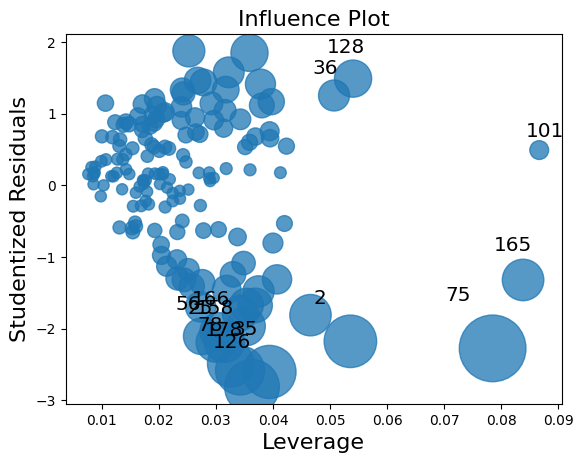

In [14]:
import statsmodels.api as sm
sm.graphics.influence_plot(model1)
plt.show()

In [15]:
df.drop(columns=['newspaper'],inplace=True)
X = df.drop(columns=['sales'])
y = df['sales']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)
print('Intercept:',model.intercept_)
print('Coefficients:',model.coef_)

ypred_train = model.predict(X_train)
print('R2 score for train data:',r2_score(y_train,ypred_train))

ypred_test = model.predict(X_test)
print('R2 score for test data:',r2_score(y_test,ypred_test))

Intercept: 2951.4407608079728
Coefficients: [0.04451639 0.19520741]
R2 score for train data: 0.906590009997456
R2 score for test data: 0.8604541663186569


In [19]:
from joblib import dump
dump(model,'multiple.joblib')

['multiple.joblib']

In [20]:
from pickle import dump 
dump(model,open('sales_model.pkl','wb'))